In [2]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import smrt
from smrt.permittivity.saline_snow import saline_snow_permittivity_geldsetzer09 as geldsetzer

In [3]:
c = 3e8
def get_speed(form,density,temperature=None,salinity=None,frequency=13.5e9):
    """ Return the radar speed from dry snow density
    density can be in g/cm3 or kg/m3
    form can be 'Ulaby','Hallikainen','Tiuri'
    string can be 'speed', 'factor' or 'wrongfactor'
    """

    speed_dict = {"Ulaby" : c*((1+0.51*density/1000)**(-1.5)),
                  'Geldsetzer':c*abs(geldsetzer(frequency,density,temperature,salinity))**-0.5,
                  "Hallikainen":c*((1+1.91*(density/1000))**(-0.5)),
                  "Tiuri":c*((1+1.7*(density/1000) + 0.7*(density/1000)**2)**(-0.5))}
    return(speed_dict[form])

In [23]:
speed=get_speed('Geldsetzer',density=250,temperature=273.15-2.4,salinity=7.9e-3)

(c/speed)

1.953229851192688

In [24]:
speed=get_speed('Geldsetzer',density=250,temperature=273.15-5,salinity=0.02e-3)

(c/speed)

1.2804094145664098

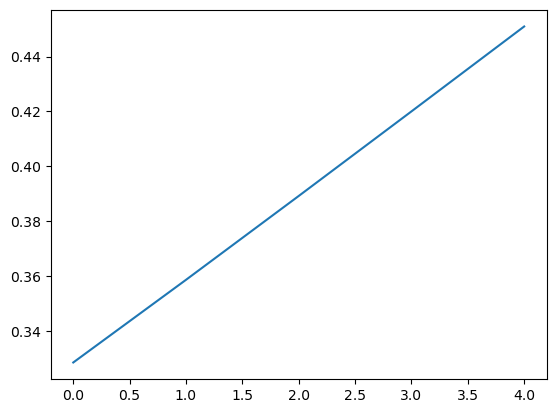

In [8]:
factors=[]
for i in range(0,5):

    speed=get_speed('Geldsetzer',density=300,temperature=273.15-7,salinity=i*1e-3)
    
    factors.append( (c/speed)-1 )

plt.plot(factors)

In [6]:
saline_snow.saline_snow_permittivity_geldsetzer09(13e9,300,269,1e-3)

(1.9135797995248172+0.15911715895117878j)

In [7]:
saline_snow.saline_snow_permittivity_geldsetzer09(13e9,300,269,7.9e-3)

(2.9235989386704633+1.2386238781498413j)